# Trajectory inference with PAGA
This notebook serves as a walkthrough for performing trajectory inference on omic data. Discussions of each step are included throughout the notebook. To execute the notebook, ensure that you have installed the requirements in your Python environment (`pip install -r requirements.txt`), then use the menu `Run -> Run Selected Cell and Below` to run the entire notebook.

Note that much of the code contained here can be found on the tutorial page of Scanpy's trajectory inference. Changes were made to examine the effects of different processing steps on the conclusion. Some notes were also added to explain what a section of code is doing.

To apply this method to your own data, you'll need to assign your data to the `adata` object below, then run the notebook again.

In [1]:
import scanpy as sc
from matplotlib import pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

Load the data published by [Paul et al. 2015, "Transcriptional Heterogeneity and Lineage Commitment in Myeloid Progenitors"](https://doi.org/10.1016/j.cell.2015.11.013). The experiment consisted of collecting hematopoietic progenitors, obtaining their transcriptome, and describing cell differentiation into terminal states.

In [2]:
adata = sc.datasets.paul15()  # Downloads the dataset and loads it
print(adata)

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'


Scanpy uses AnnData objects to store data; it consists of a data matrix "X" with dimensions (`samples` x `features`), or (`observations` x `variables`), along with observation-level metadata.

In the above summary: `n_obs x n_vars = 2730 x 3451` indicates that there are 2730 observations, and that each one has 3451 variables (genes, in this case).

`obs:` gives the list of observation-level metadata; this is additional non-gene data associated with every sample. Here, we have `paul15_clusters`, which are clusters determined by the Paul et al. 2015 paper. Your data is likely to contain values such as `batch`, `disease`, or `species`.

`uns:` contains a dictionary of unstructured metadata. In this case, it contains `iroot`, which is used later for computing pseudotime.

## Preprocessing
scRNA-seq data is typically preprocessed to remove variance introduced by measuring instruments, or more generally to rmeove influences on the data that are not biologically-driven.

Count normalization is used to account for differences in the total number of reads; it assumes that each samples should have the same totals. Note that there are other methods of normalization that might be more appropriate for your own data.
We visualize the distribution of totals before normalization:

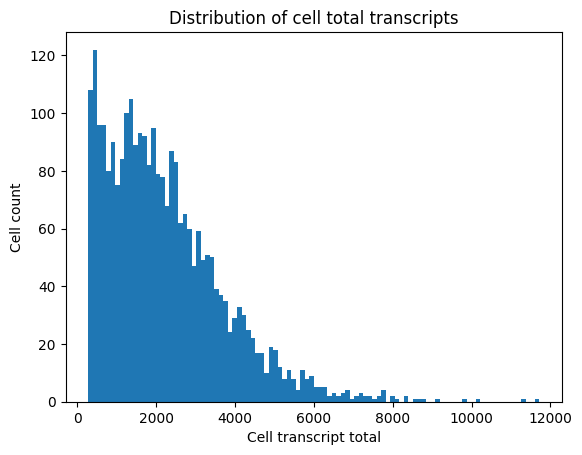

In [3]:
_ = plt.hist(np.sum(adata.X, axis=1), bins=100)
plt.xlabel("Cell transcript total")
plt.ylabel("Cell count")
_ = plt.title("Distribution of cell total transcripts")

In [4]:
sc.pp.normalize_total(adata)  # Normalize to some total.

scRNA-seq has a large dynamic range, potentially spanning across orders of magnitude. In order to better compare values or changes between groups, we take the natural log of the data. Changes can later be expressed in log-fold change.

In the case of the `paul15_dataset`, the dynamic range is fairly small with most data in the (post-normalized) range of 0-5. We will still take the log of the data to make it comparable to other analyses.

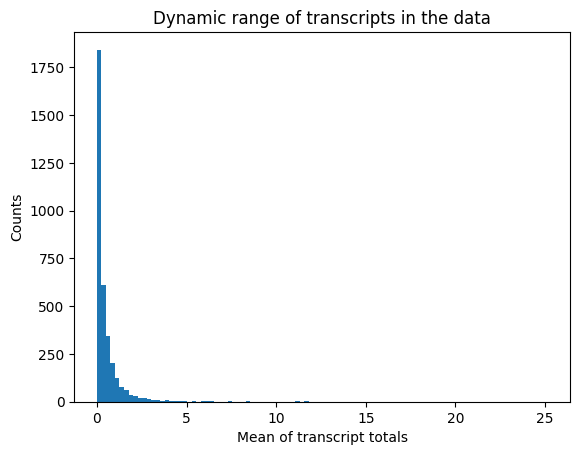

In [5]:
_ = plt.hist(np.mean(adata.X, axis=0), bins=100)
plt.xlabel("Mean of transcript totals")
plt.ylabel("Counts")
_ = plt.title("Dynamic range of transcripts in the data")

In [6]:
sc.pp.log1p(adata)  # Take the natural log of the data.
# "1p" indicates that the values have '1' added to them first: log(x+1). This is done to avoid errors with log(0).

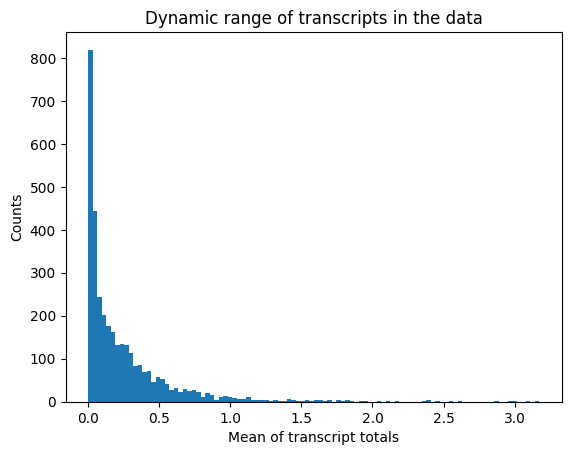

In [7]:
_ = plt.hist(np.mean(adata.X, axis=0), bins=100)
plt.xlabel("Mean of transcript totals")
plt.ylabel("Counts")
_ = plt.title("Dynamic range of transcripts in the data")

Lastly, we will rescale the data so that it has a mean of 0 and a variance of 1.

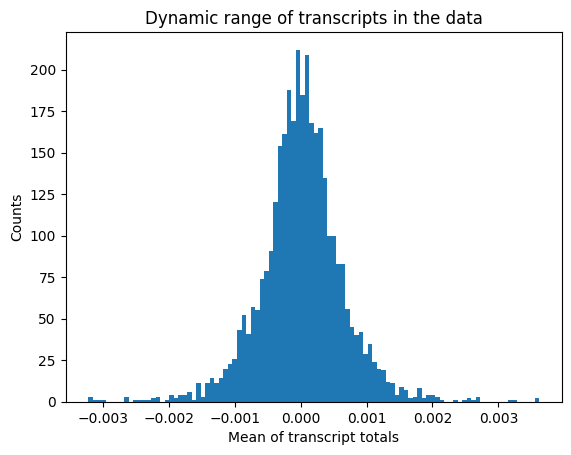

In [8]:
sc.pp.scale(adata)  # rescale to 0 mean and variance of 1
_ = plt.hist(np.sum(adata.X, axis=0), bins=100)
plt.xlabel("Mean of transcript totals")
plt.ylabel("Counts")
_ = plt.title("Dynamic range of transcripts in the data")

#### Computing the neighborhood

PAGA relies on k-nearest neighbors (kNN) for computing its connectivity. Scanpy has a preprocessing step (sc.pp.neighbors) that will compute this quickly using PCA. For our purposes, the default settings can be kept.  

`n_neighbors` is important for controlling the locality of the neighborhoods; low values indicate that only the closest samples are considered as part of a neighborhood, while large values will consider more samples and have larger neighborhoods.  

`n_pcs` controls the number of principal components to be used when computing the distance distance between samples.

In [9]:
sc.tl.pca(adata, svd_solver="arpack")  # since neighbors() uses PCA values, compute them explicitly here
sc.pp.neighbors(adata, n_neighbors=4, n_pcs=20)  # compute the kNN distances

We can now visualize the high-dimensional data in 2D by estimating the topology using a force-directed graph. Once plotted, the x- and y-axes are labeled as "FA1", "FA2"; these are components determined by the implementation.

Note that although some effort is made to retain distances between groups, information is necessarily lost when reducing the data to only 2 dimensions. The visualization is good for getting a sense of the shape, but direct comparisons ("group A is further than group B from group C") should generally be avoided in this space.

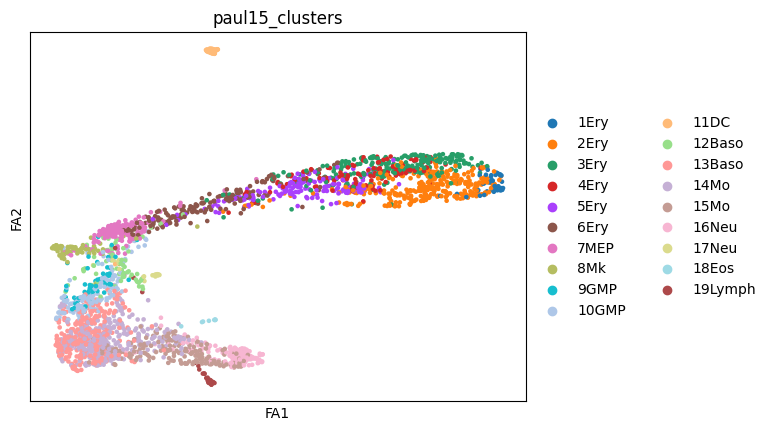

In [10]:
sc.tl.draw_graph(adata)  # compute the graph
sc.pl.draw_graph(adata, color="paul15_clusters")  # display the graph

Most data is connected to a central curve, with some offshoots. Some of the clusters are entirely separate from the curve. The labels are provided with the dataset; for your own data, you would need to determine cell type labels separately.

## Trajectory inference with PAGA
Now that we've processed the data and seen a low-dimensional representation, we can perform trajectory inference using PAGA. The first step is to compute clusters. Below, we plot the clusters next to the dataset labels for comparison. You should see a coarse but imperfect agreement between the two.

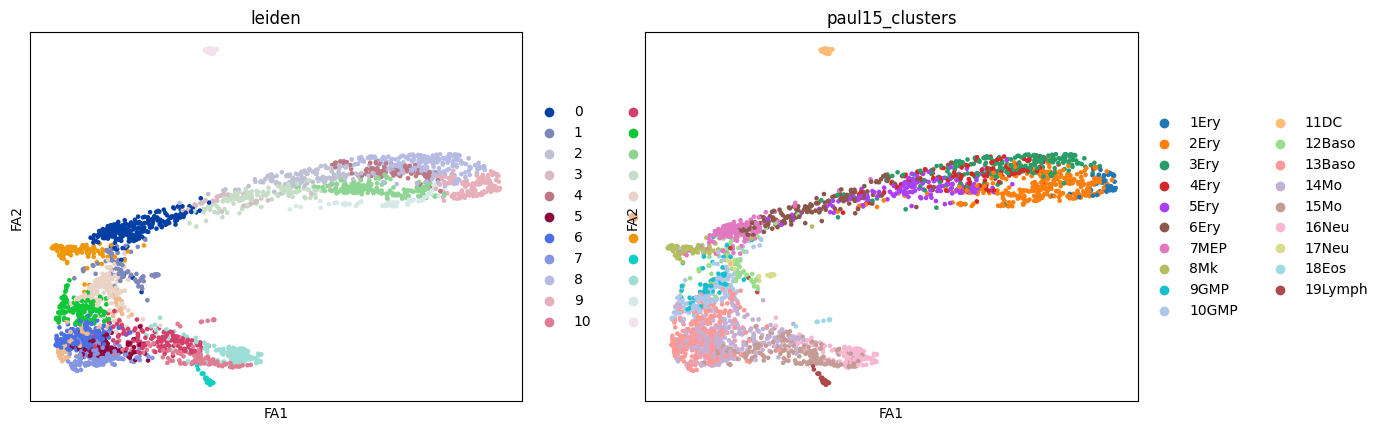

In [11]:
sc.tl.leiden(adata, resolution=1, flavor="igraph", n_iterations=2)  # leiden clustering
sc.pl.draw_graph(adata, color=["leiden", "paul15_clusters"])  # display the graph

We'll now compute the PAGA graph using the Leiden clusters and plot the resulting nodes. You'll note that distribution of labels is different than in the previous plot (ignore that for now).

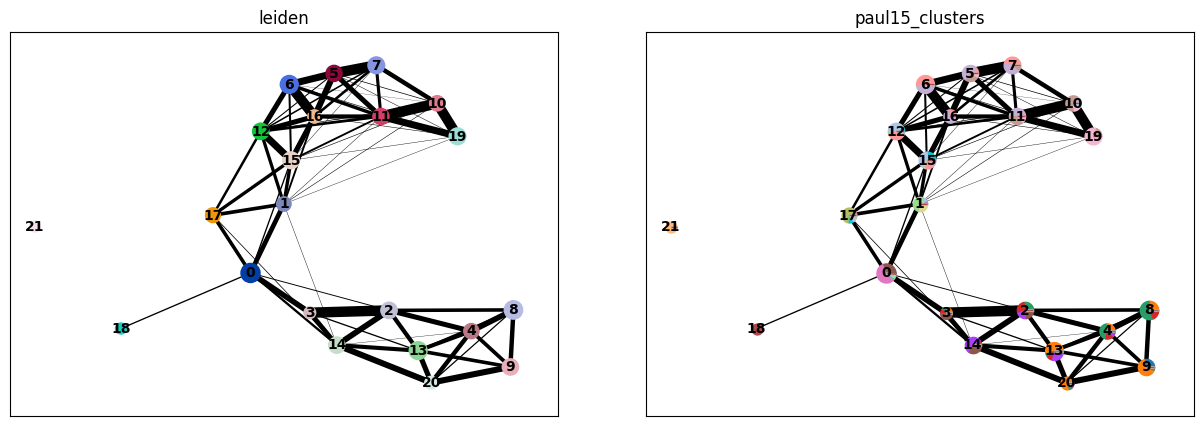

In [12]:
sc.tl.paga(adata, groups="leiden")
sc.pl.paga(adata, color=["leiden", "paul15_clusters"])

The plot on the left ("leiden") shows the connectivities between Leiden groups. Thicker edges represent stronger connections, thinner ones are weaker.  

The plot on the right ("paul15_clusters") is the same, but with the nodes showing pie charts of the labels contained at the node. Single-colored nodes indicate a strong agreement between the Leiden clusters and the dataset labels.

The graph is also useful for showing the distribution of gene expression across clusters. For example, looking at Hba-a2 (hemoglobin variant) and ELANE (neutrophil elastase):

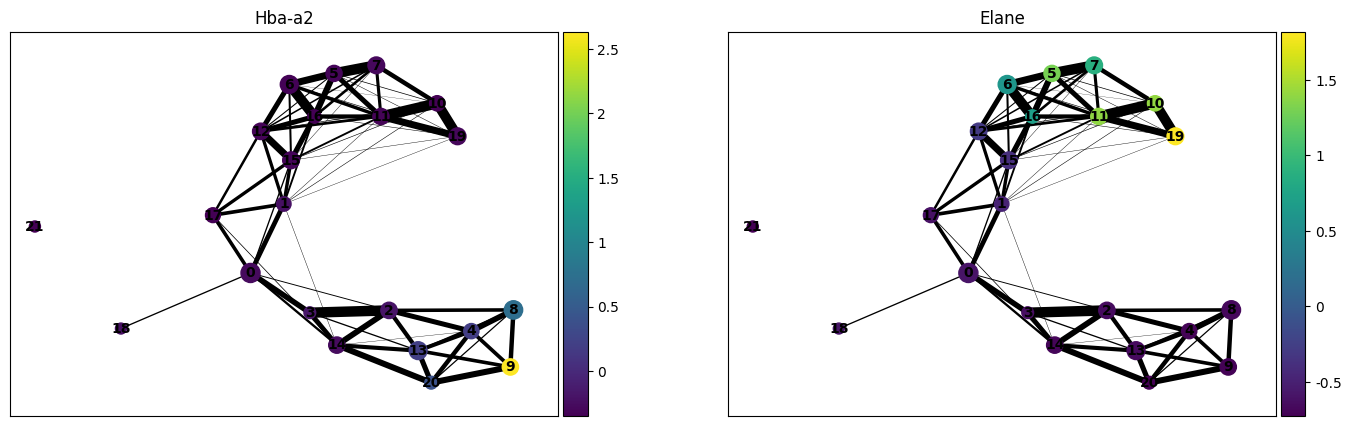

In [13]:
sc.pl.paga(adata, color=["Hba-a2", "Elane"])

As expected, nodes typically contain either `Hba-a2` or `Elane`, but not both.

The PAGA graph is inherently a coarse view of the data. To show the graph at the full resolution of the data, we can recompute the 2D representation, but this time start with the PAGA graph. As before, we can display specific genes.

In [14]:
sc.tl.draw_graph(adata, init_pos="paga")

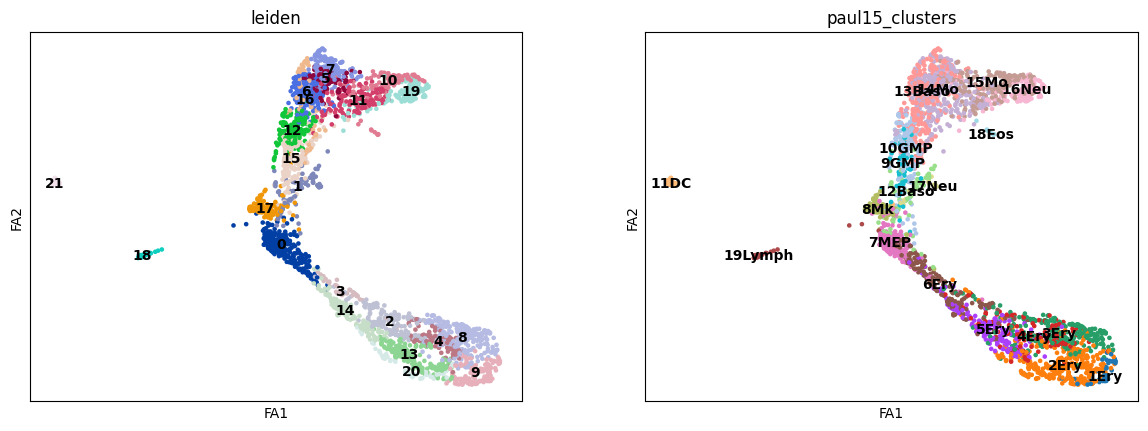

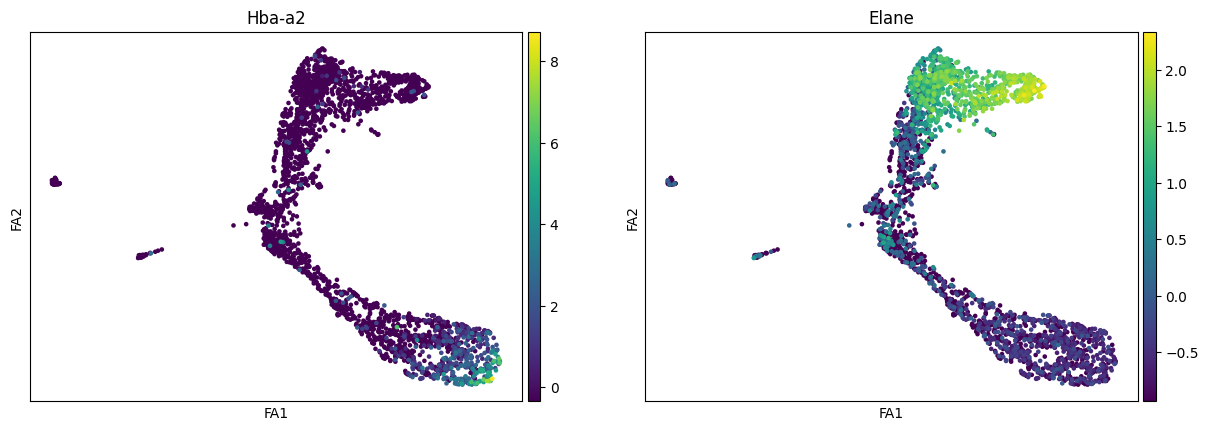

In [15]:
sc.pl.draw_graph(adata, color=["leiden", "paul15_clusters"], legend_loc="on data")
sc.pl.draw_graph(adata, color=["Hba-a2", "Elane"])

We can visualize the single-sample resolution with the PAGA nodes side-by-side using `paga_compare`:

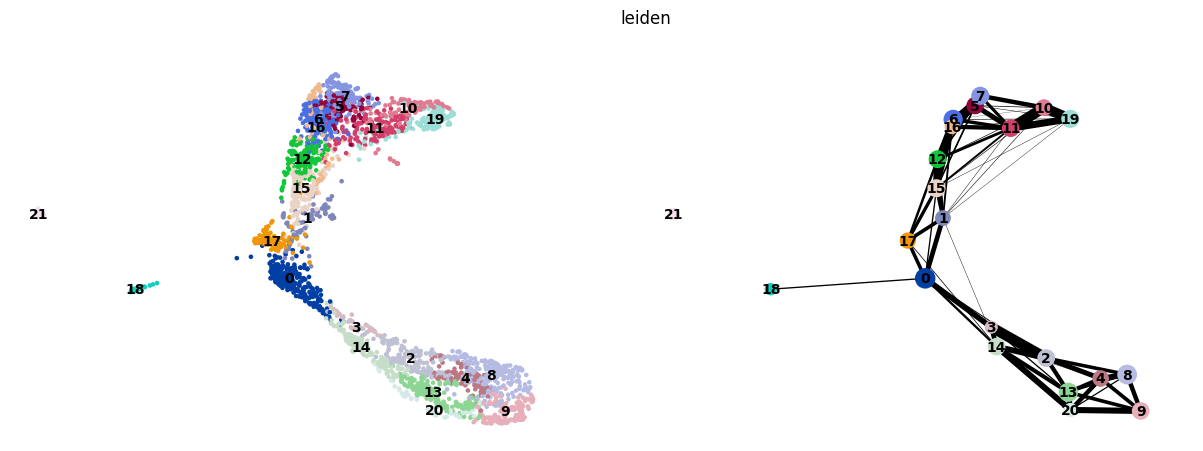

[<Axes: xlabel='FA1', ylabel='FA2'>, <Axes: >]

In [16]:
sc.pl.paga_compare(adata)  # Side-by-side comparison of sample-resolution and PAGA nodes.

### Pseudotime 
Clustering cells by connectivities is useful for obtaining an intuitive grouping; however, we know that cell transcriptomics can vary continuously between cell states. A cell that differentiates into a different cell does not have its transcriptome change instantly. We can estimate this sort of transition using *pseudotime*.  

A note of caution: pseudotime is **not** inherently a measure of time, differentiation, or disease progression. It is a measure of distance between omic profiles: similar cells are close together in pseudotime because they have similar profiles. Pseudotime **can** be linked to measures of time, but only when combined with another measure such as marker genes or disease status. We will illustrate the concept below.

`scanpy` uses diffusion pseudotime ([Haghverdi et al.](https://doi.org/10.1038/nmeth.3971)) to compute pseudotime, which first requires us to compute the diffusion map.

In [17]:
sc.tl.diffmap(adata)  # compute diffusion map
sc.tl.dpt(adata)  # compute diffusion pseudotime

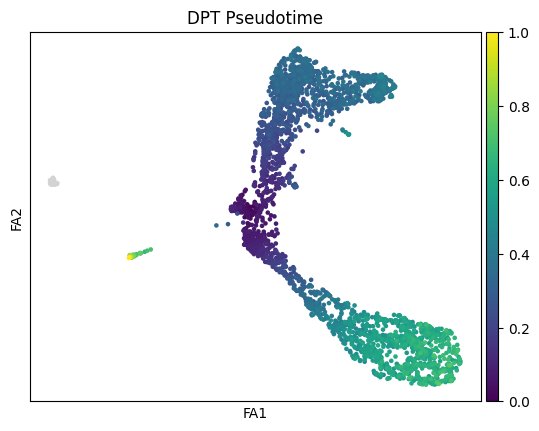

In [18]:
# fig, ax = plt.subplots()
ax = sc.pl.draw_graph(adata, color=["dpt_pseudotime"], show=False)
ax.set_title("DPT Pseudotime")
fig = ax.get_figure()
fig.savefig("dpt_pseudotime.svg")
fig.savefig("dpt_pseudotime.png")
fig.savefig("dpt_pseudotime.pdf")

There are a few things to notice about this plot.

Pseudotime varies from 0.0 (first) to 1.0 (last), but these values are arbitrary; other implementations could use the order index instead.  

There is a disconnected cluster; since it is not connected in the PAGA graph, its pseudotime cannot be computed.

Depending on the settings used to process the data, you should see that pseudotime ("PT") starts near the center of the graph, and splits into three branches (two large ones, one small). One might conclude that cells at PT=0 differentiate to two different branches, but this is incorrect on its own. One *must not* conclude that a particular process starts at PT=0 unless there is external information to justify why PT=0 is the start of that process. In this case, the dataset contained additional information when it was loaded: `iroot`.

In [19]:
adata.uns["iroot"]  # Root cell

840

`iroot` indicates to the DPT computation where it should start; it is the index of a cell in the dataset. Any conclusions drawn from only the pseudotime can be changed simply by changing where pseudotime should start from:

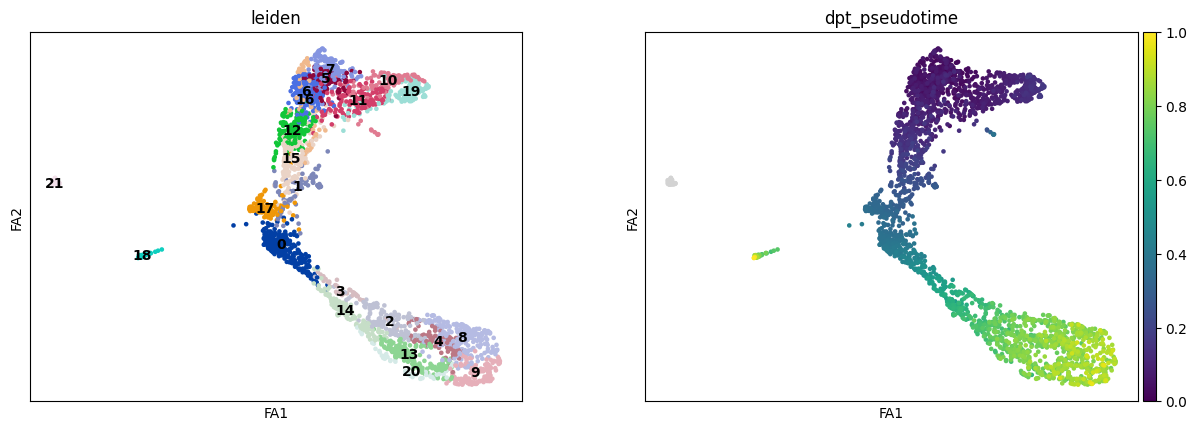

In [20]:
orig_iroot = adata.uns["iroot"]
adata.uns["iroot"] = 1
sc.tl.diffmap(adata)  # compute diffusion map
sc.tl.dpt(adata)  # compute diffusion pseudotime
sc.pl.draw_graph(adata, color=["leiden", "dpt_pseudotime"], legend_loc="on data")

Using this graph, we would conclude that there are only two branches (one large, one small) and that the cells at PT=0 differentiate into cells at the narrow band, which then differentiate to the large cluster. Using the cell labels in the original dataset, this would correspond to white blood cells differentiating into stem cells and then into red blood cells.

The original value of `iroot` was selected because gene markers indicated that that cell corresponded to a stem cell. With that additional information, it makes sense to link pseudotime to differentiation. Let's restore the original value for `iroot`.

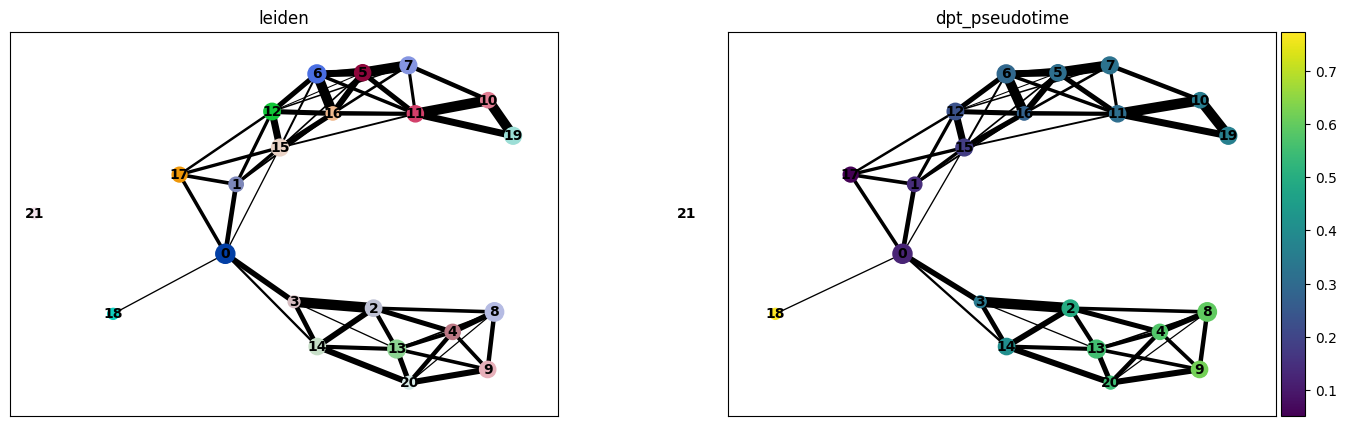

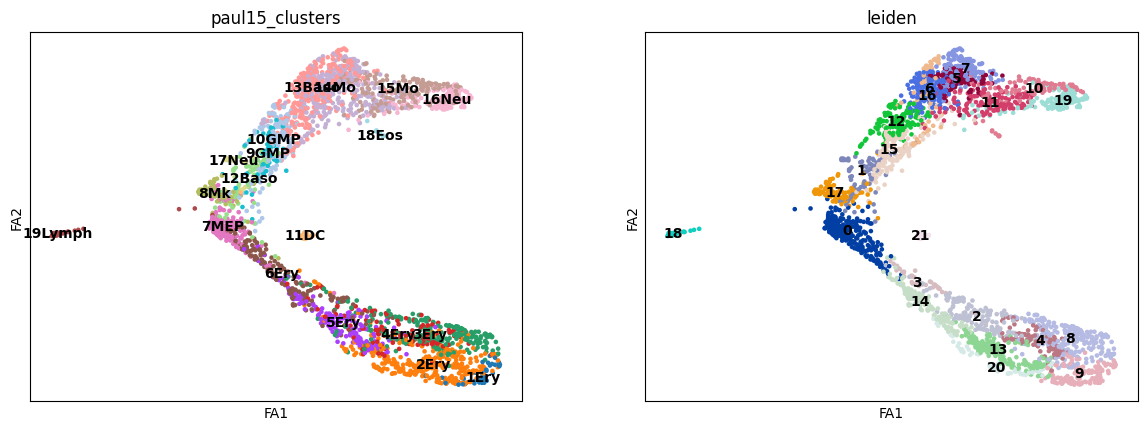

In [21]:
adata.uns["iroot"] = orig_iroot
sc.tl.diffmap(adata)  # compute diffusion map
sc.tl.dpt(adata)  # compute diffusion pseudotime
sc.pl.paga(adata, color=["leiden", "dpt_pseudotime"], threshold=0.1)
sc.tl.draw_graph(adata, init_pos="paga")
sc.pl.draw_graph(adata, color=["paul15_clusters", "leiden"], legend_loc="on data")  # display the graph

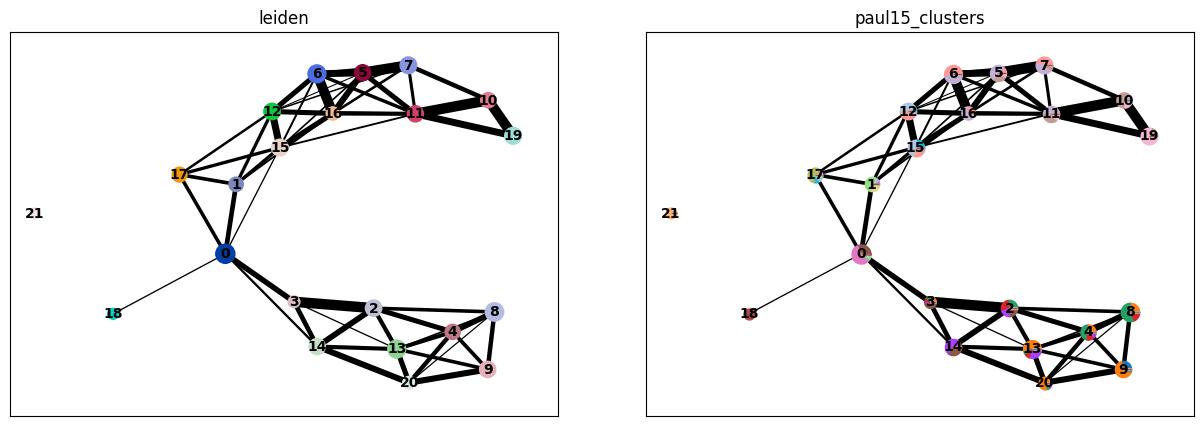

In [22]:
sc.pl.paga(adata, color=["leiden", "paul15_clusters"], threshold=0.1)

In [23]:
adata[840,:].obs

,paul15_clusters,leiden,dpt_pseudotime
W37022,8Mk,17,0.0


#### Expression changes along pseudotime
To visualize the change in gene expression along differentiation, we need to specify the cluster labels along which we think the cells are differentiating. Examing the graphs, we'll start at the stem cell and proceed along paths for erythrocytes, neutrophils, and monocytes.
The following list of genes was taken from [Scanpy's PAGA tutorial](https://scanpy.readthedocs.io/en/stable/tutorials/trajectories/paga-paul15.html).

In [24]:
gene_names = [
    "Gata2", "Gata1", "Klf1", "Epor", "Hba-a2",  # erythroid
    "Elane", "Cebpe", "Gfi1",  # neutrophil
    "Irf8", "Csf1r", "Ctsg",  # monocyte
]

In [25]:
erythrocyte_path = [16, 1, 13, 17, 20, 5, 18]
neutrophils_path = [16, 6, 2, 7]
monocytes_path = [16, 6, 2, 11, 15]

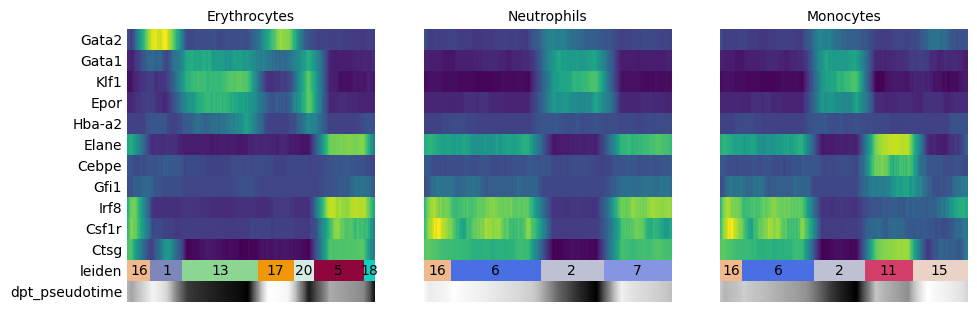

In [26]:
adata.obs["distance"] = adata.obs["dpt_pseudotime"]
_, ax = plt.subplots(ncols=3, figsize=(12,3))
sc.pl.paga_path(adata, erythrocyte_path, gene_names, n_avg=50, ax=ax[0], show_colorbar=False, title="Erythrocytes")
sc.pl.paga_path(adata, neutrophils_path, gene_names, n_avg=50, ax=ax[1], show_colorbar=False, title="Neutrophils", show_yticks=False)
sc.pl.paga_path(adata, monocytes_path, gene_names, n_avg=50, ax=ax[2], show_colorbar=False, title="Monocytes", show_yticks=False)

Let's first understand what the plot is showing:

Every column in the plot represents an block of cells averaged together (set by the `n_avg` parameter above). The cells are ordered by the Leiden group we specified by the path displayed at the bottom; in the Erythrocyte plot, we progress through clusters 16, 1, 13, 17, etc. Along with the group, we also see the pseudotime for the corresponding groups.

The genes displayed on the left are the marker genes we selected. GATA2 is a transcription factor that plays a role in blood cell progenitors and its higher levels in early parts of pseudotime are consistent of that. GATA1 is another transcription factor used by erythrocytes; having its quantities increase along the erythrocyte path is also consistent with differentiation. Similarly for the neutrophil markers.

However, the monocyte marker quantities don't seem consistent with known markers. In particular, the distribution of cluster 15 appears more consistent with neutrophils than monocytes. We can change the path specification to finalize on cluster 3 instead and plot again:

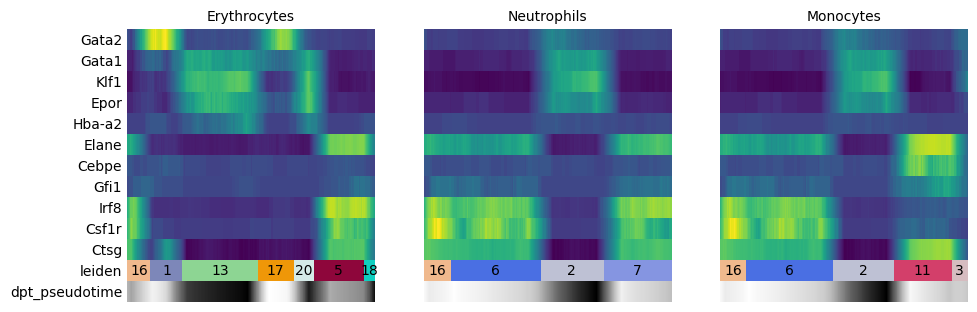

In [27]:
monocytes_path = [16, 6, 2, 11, 3]
_, ax = plt.subplots(ncols=3, figsize=(12,3))
sc.pl.paga_path(adata, erythrocyte_path, gene_names, n_avg=50, ax=ax[0], show_colorbar=False, title="Erythrocytes")
sc.pl.paga_path(adata, neutrophils_path, gene_names, n_avg=50, ax=ax[1], show_colorbar=False, title="Neutrophils", show_yticks=False)
sc.pl.paga_path(adata, monocytes_path, gene_names, n_avg=50, ax=ax[2], show_colorbar=False, title="Monocytes", show_yticks=False)

The updated plot is much more consistent with known markers than before. You may notice that the pseudotime bar does not strictly increase; the general trend should be for it to increase from stem cell towards terminal states. However, fine-resolution clustering, noisy samples, or undersampled data can cause some cells in downstream clusters to have a smaller pseudotime than cells in previous clusters. Methods for estimating pseudotime measure paths from some root cell, and these paths could also differ from the selected paths.

While computational approaches are useful for furthering our understanding of complex datasets, it is important to evaluate their results and contextualize new findings with established biology.
